# Figure 1 · The cantilever transfer function, mapped: a stiff and a soft probe

Production notebook for main-text Fig. 1 (Nature Communications style, 180 mm).
The paper uses two probes: a **stiff probe** (SCM-PIT, k = 1.70 N/m; run R2, 20–21 Sep) and a
**soft probe** (PPP-CONTAu, k = 0.41 N/m). The stiff probe's first run (R1) and the earlier
SCM-PIT lever (Grid B) are in the SI.

- **a** Measurement schematic (`fmmpaper.schematic`): the laser spot is stepped along a lever whose tip is
  in contact with a two-domain PPLN sample.
- **b, c** Dense ground-truth maps |Z(x, f)| in dB, positions measured from the clamp:
  - stiff probe: 161 positions at 1 µm, 500 nN, 192 min; lever frame x − x₀ with x₀ = 28.1 µm
    during the map (frame anchors, notebook 05a);
  - soft probe: 346 positions at 1 µm, 100 nN, 410.6 min; clamp at stage −19.0 µm (static-shape
    ruler, Phase 2g).
- **d, e** On-resonance mode shapes of every contact resonance, with the nodes.
- **f** Time to map: dense reference vs the live sparse capture on the same probe.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
X0_STIFF, X0_SOFT = 28.1, -19.0
st = F.load("scmpitB_r2_dense"); sp = F.load("ppp_dense_1um")
PROBES = {"stiff": dict(s=st, x=st.x_um - X0_STIFF, fmax=2000, bands=["CR1", "CR2", "CR3"], name="Stiff probe",
                        sub="161 positions · 192 min"),
          "soft": dict(s=sp, x=sp.x_um - X0_SOFT, fmax=1100, bands=["CR1", "CR2", "CR3", "CR4", "CR5"], name="Soft probe",
                       sub="346 positions · 411 min")}
import json
TRUTH_SOFT = json.loads((F.config.RESULTS_DIR / "fig3_ppp_per_mode.json").read_text())["values"]["truth_nodes"]   # vetted nodes (02a), stage x
PROF = {}
for k, P in PROBES.items():
    for b in P["bands"]:
        pk = spectra.peaks_along_x(P["s"].freq_Hz, P["s"].Z[0], P["s"].probe.bands_Hz[b])
        f0, v = spectra.on_resonance_profile(P["s"].freq_Hz, P["s"].Z[0], P["s"].probe.bands_Hz[b])
        a = np.abs(v) / np.abs(v).max()
        nd = ([n - X0_SOFT for n in TRUTH_SOFT[b]] if k == "soft" else
              [n for n in spectra.nodes_from_profile(P["x"], a) if P["x"].min() + 5 <= n <= P["x"].max() - 5])
        PROF[(k, b)] = dict(a=a, f0=f0, nodes=nd, Q=float(np.nanmedian(pk["Q"])))
pd.DataFrame([dict(probe=k, mode=b, f_kHz=v["f0"] / 1e3, Q=v["Q"], nodes_um=np.round(v["nodes"], 1).tolist())
              for (k, b), v in PROF.items()]).round(1)

,probe,mode,f_kHz,Q,nodes_um
0,stiff,CR1,295.3,244.7,[]
1,stiff,CR2,915.0,350.7,[124.9]
2,stiff,CR3,1837.4,271.2,"[88.9, 156.9]"
3,soft,CR1,65.0,120.0,[453.0]
4,soft,CR2,201.8,265.7,"[254.0, 455.0]"
5,soft,CR3,414.1,357.6,"[178.0, 314.0]"
6,soft,CR4,694.5,327.8,"[138.0, 244.0, 349.0]"
7,soft,CR5,1023.7,199.2,"[201.0, 290.5, 375.0]"


In [3]:
TIMES = pd.DataFrame([
    dict(probe="Stiff probe", dense_min=192.0, n_dense=161, sparse_min=9.6, n_sparse=8),
    dict(probe="Soft probe", dense_min=410.6, n_dense=346, sparse_min=13.8, n_sparse=12)])
TIMES["speedup"] = TIMES.dense_min / TIMES.sparse_min
TIMES.round(1)

,probe,dense_min,n_dense,sparse_min,n_sparse,speedup
0,Stiff probe,192.0,161,9.6,8,20.0
1,Soft probe,410.6,346,13.8,12,29.8


## The figure

[PosixPath('/home/claude/work/paper_analysis/figures/Fig1_why_and_how_fast.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/Fig1_why_and_how_fast.pdf')]

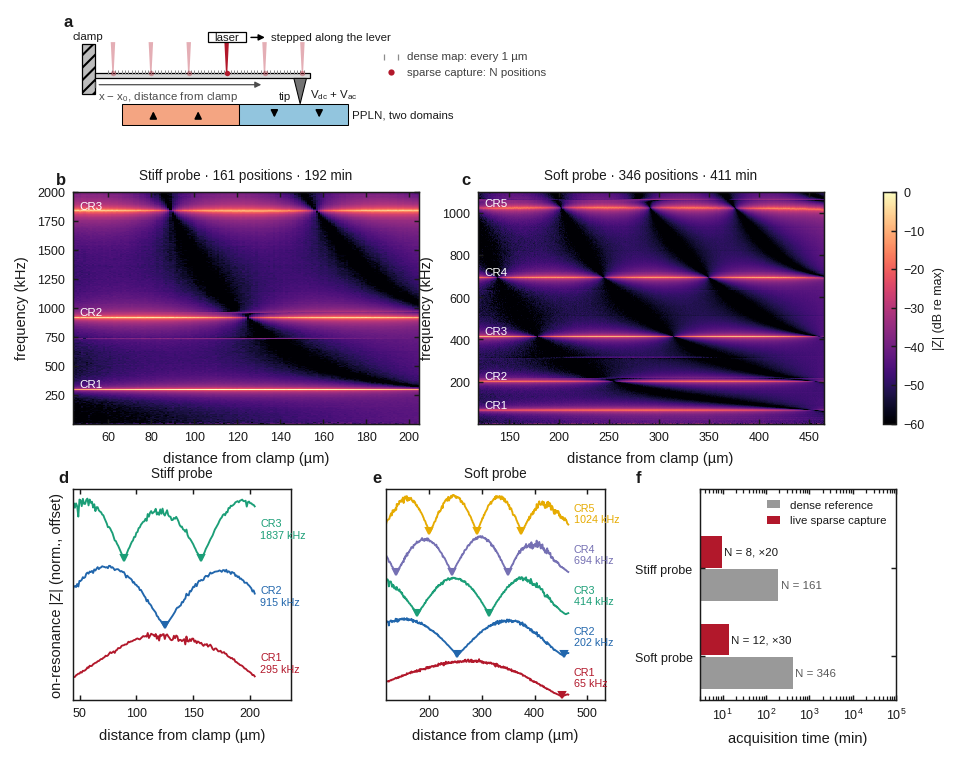

In [4]:
from matplotlib.gridspec import GridSpec
from fmmpaper import schematic
fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.83))
gs = GridSpec(3, 1, figure=fig, height_ratios=[0.5, 1.1, 1], hspace=0.36)
axs0 = fig.add_subplot(gs[0]); schematic.draw(axs0); fp.panel_label(axs0, "a", dx=0.0, dy=0.92)
g1 = gs[1].subgridspec(1, 3, width_ratios=[1, 1, 0.04], wspace=0.25)
g2 = gs[2].subgridspec(1, 3, width_ratios=[1, 1, 0.9], wspace=0.45)
for i, k in enumerate(("stiff", "soft")):
    P = PROBES[k]; ax = fig.add_subplot(g1[0, i])
    im = fp.map_db(ax, P["x"], P["s"].freq_Hz, P["s"].Z[0], fmax=P["fmax"], colorbar=False)
    ax.set_title(f"{P['name']} · {P['sub']}", fontsize=6.5)
    ax.set_xlabel("distance from clamp (µm)"); ax.set_ylabel("frequency (kHz)")
    for b in P["bands"]:
        ax.text(0.02, PROF[(k, b)]["f0"] / 1e3, b, transform=ax.get_yaxis_transform(), color="w", fontsize=5.5, va="bottom")
    fp.panel_label(ax, "bc"[i])
cb = fig.colorbar(im, cax=fig.add_subplot(g1[0, 2])); cb.set_label("|Z| (dB re max)", fontsize=6)
for i, k in enumerate(("stiff", "soft")):
    P = PROBES[k]; ax = fig.add_subplot(g2[0, i])
    for j, b in enumerate(P["bands"]):
        pr = PROF[(k, b)]; c = fp.C[b.lower()]
        ax.plot(P["x"], pr["a"] + 1.1 * j, color=c, lw=0.9)
        for nd in pr["nodes"]:
            ax.plot(nd, 1.1 * j + 0.03, "v", color=c, ms=3)
        ax.text(P["x"].max() + 0.03 * np.ptp(P["x"]), 1.1 * j + 0.5, f"{b}\n{pr['f0']/1e3:.0f} kHz", color=c, fontsize=5.2, va="center")
    ax.set_xlim(P["x"].min(), P["x"].max() + 0.2 * np.ptp(P["x"])); ax.set_ylim(-0.1, 1.1 * len(P["bands"]) + 0.05)
    ax.set_yticks([]); ax.set_xlabel("distance from clamp (µm)")
    ax.set_ylabel("on-resonance |Z| (norm., offset)" if i == 0 else "")
    ax.set_title(P["name"], fontsize=6.5)
    fp.panel_label(ax, "de"[i])
axe = fig.add_subplot(g2[0, 2]); yy = np.arange(len(TIMES))
axe.barh(yy + 0.19, TIMES.dense_min, height=0.36, color="0.6", label="dense reference")
axe.barh(yy - 0.19, TIMES.sparse_min, height=0.36, color=fp.C["ebgp"], label="live sparse capture")
for i, r in TIMES.iterrows():
    axe.text(r.sparse_min * 1.15, i - 0.19, f"N = {r.n_sparse}, ×{r.speedup:.0f}", va="center", fontsize=5.5)
    axe.text(r.dense_min * 1.15, i + 0.19, f"N = {r.n_dense}", va="center", fontsize=5.5, color="0.35")
axe.set_xscale("log"); axe.set_xlim(3, 1e5); axe.set_ylim(1.5, -0.9); axe.set_yticks(yy); axe.set_yticklabels(TIMES.probe, fontsize=6)
axe.set_xlabel("acquisition time (min)")
axe.legend(loc="upper right", fontsize=5.5, handlelength=1.2)
fp.panel_label(axe, "f", dx=-0.3)
fp.save(fig, "Fig1_why_and_how_fast")

In [5]:
results.save("fig1_main", dict(times=TIMES.to_dict("records"), x0_stiff=X0_STIFF, x0_soft=X0_SOFT,
                               modes=[dict(probe=k, mode=b, f_kHz=v["f0"] / 1e3, Q=v["Q"], nodes_um=v["nodes"]) for (k, b), v in PROF.items()]),
             table=TIMES)

PosixPath('/home/claude/work/paper_analysis/results/fig1_main.json')